# Modeling

In [1]:
from pathlib import Path
from typing import Optional
import sys
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.evaluation.evaluate import compare_models
from src.feature_engineering.build_features import build_feature_set
from src.models.train import train_models
from src.utils.helpers import ensure_dir, get_project_root, save_json, save_model

In [2]:
def find_project_root(start: Optional[Path] = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data" / "heart.csv").exists():
            return candidate
    raise FileNotFoundError("Project root not found (expected data/heart.csv)")
ROOT = find_project_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

## Build Feature Set

In [3]:
feature_set = build_feature_set()
print("X_train:", feature_set.X_train.shape)
print("X_test:", feature_set.X_test.shape)
print("Feature count:", len(feature_set.feature_names))
display(feature_set.X_train.head())

X_train: (242, 18)
X_test: (61, 18)
Feature count: 18


,age,sex,trestbps,chol,fbs,thalach,exang,oldpeak,slope,ca,cp_1,cp_2,cp_3,restecg_1,restecg_2,thal_1,thal_2,thal_3
269,99.775363,1,1.652121,4.044511,1,34193.227632,1,0.490856,0,0,False,False,False,False,False,False,False,True
191,104.060287,1,1.651135,3.909224,0,61564.640490,1,0.846853,1,3,False,False,False,False,False,False,False,True
15,87.096593,0,1.646936,3.916243,0,97354.894861,0,0.490856,1,0,False,True,False,True,False,False,True,False
224,95.519188,1,1.641027,3.960431,0,55975.891019,1,1.130195,1,1,False,False,False,True,False,False,False,True
250,89.190732,1,1.656715,4.069855,0,51729.486474,1,1.634849,1,3,False,False,False,True,False,False,False,True


## Train & Evaluate Models
The parameter sets were optimized using `GridSearchCV` with `recall` as the primary metric during tuning.

In [4]:
trained_models = train_models(feature_set.X_train, feature_set.y_train)
model_pairs = [(trained.name, trained.estimator) for trained in trained_models]
evaluation_table = compare_models(model_pairs, feature_set.X_test, feature_set.y_test)
display(evaluation_table)

,precision_0,precision_1,recall_0,recall_1,f1_0,f1_1,macro_avg_precision,macro_avg_recall,macro_avg_f1,accuracy
SVM,0.00,0.54,0.00,1.00,0.00,0.70,0.27,0.50,0.35,0.54
RF,0.85,0.83,0.79,0.88,0.81,0.85,0.84,0.83,0.83,0.84
KNN,0.82,0.85,0.82,0.85,0.82,0.85,0.83,0.83,0.83,0.84
DT,0.73,0.81,0.79,0.76,0.76,0.78,0.77,0.77,0.77,0.77


### Select Best Model

In [5]:
best_model_name = evaluation_table.index[0]
best_params = next(item.best_params for item in trained_models if item.name == best_model_name)
print("Best model:", best_model_name)
display(pd.DataFrame([best_params], index=[best_model_name]))

Best model: SVM


,svm__C,svm__gamma,svm__kernel
SVM,0.01,scale,rbf


## Save Models & Reports

In [6]:
root = get_project_root()
model_dir = ensure_dir(root / "models")
report_dir = ensure_dir(root / "reports")
for trained in trained_models:
    save_model(trained.estimator, model_dir / f"{trained.name.lower()}_model.pkl")
evaluation_table.to_csv(report_dir / "model_results.csv", index=True)
save_json({"best_model": best_model_name, "best_params": best_params}, report_dir / "best_model.json")
print("Saved models to:", model_dir)
print("Saved reports to:", report_dir)

Saved models to: C:\Users\Nhi Chan\Documents\Document\Workplace\Heart-Disease-Prediction\models
Saved reports to: C:\Users\Nhi Chan\Documents\Document\Workplace\Heart-Disease-Prediction\reports


## Visualize Model Performance

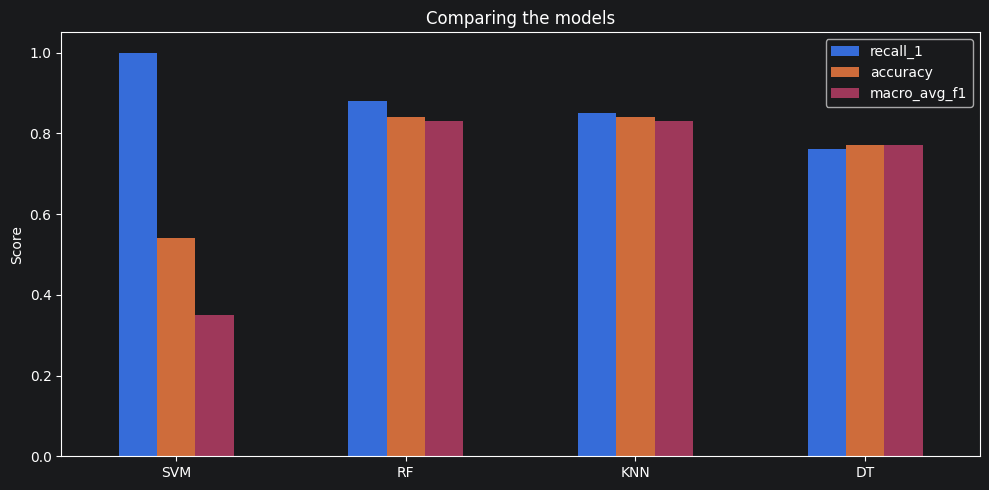

In [9]:
ax = evaluation_table[["recall_1", "accuracy", "macro_avg_f1"]].plot(kind="bar", figsize=(10, 5))
ax.set_title("Comparing the models")
ax.set_ylabel("Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## Conclusion
- `SVM` yields the highest `recall_1` but significantly lower accuracy.
- `RF` and `KNN` have more balanced performance.
- If the primary goal is to detect as many cases as possible, prioritizing `recall_1` is reasonable.